# Step 3 - PreProcessing

In [61]:
import re
import time
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats

In [62]:
#set plot formatting to seaborn's default
sns.set() 

In [63]:
%matplotlib inline

# Loading the cleaned NBA dataset from Step 2 - EDA

In [64]:
df = pd.read_csv('../Data/nba-2-eda.csv')
df.head().T

,0,1,2,3,4
player,Luka Dončić,Shai Gilgeous-Alexander,Jaylen Brown,Kevin Durant,Tyrese Maxey
team,LAL,OKC,BOS,HOU,PHI
gp,64,68,71,78,70
min,2289,2259,2443,2840,2661
fgm,693,731,736,716,694
fga,1457,1321,1543,1376,1501
fg_pct,0.476,0.553,0.477,0.52,0.462
fg3m,254,115,140,186,220
fg3a,694,298,404,450,599
fg3_pct,0.366,0.386,0.347,0.413,0.367


In [65]:
df.shape

(379, 34)

# Check for missing salaries

In [66]:
# Missing salaries are mainly for two-way (G-League) contracts
no_sal = df[df["salary"].isna()].sort_values("min", ascending=False)
print(f"players: {len(df)} | with salary: {df['salary'].notna().sum()} | without: {len(no_sal)}")
no_sal[["player", "team", "gp", "min"]].head(10)   

players: 379 | with salary: 363 | without: 16


,player,team,gp,min
218,Egor Dëmin,BKN,52,1308
274,Ryan Nembhard,DAL,60,1171
288,Jamir Watkins,WAS,50,1032
232,Caleb Love,POR,49,1013
352,Dylan Cardwell,SAC,44,907
253,Quenton Jackson,IND,49,897
301,Daeqwon Plowden,SAC,32,844
275,Javon Small,MEM,41,830
342,Pete Nance,MIL,47,737
311,Sharife Cooper,WAS,41,700


# Convert to per 36 minutes

In [67]:
# Raw totals conflate "good" with "played a lot." 
# Note: REB is excluded (= OREB + DREB, an exact identity)

count_features = ["pts", "oreb", "dreb", "ast", "stl", "blk", "tov", "fga", "fg3a", "fta", "pf"]
for c in count_features:
    df[f"{c}_36"] = df[c] / df["min"] * 36

df["mpg"] = df["min"] / df["gp"]   # minutes per game = coach's trust / role size
df

,player,team,gp,min,fgm,fga,fg_pct,fg3m,fg3a,fg3_pct,...,dreb_36,ast_36,stl_36,blk_36,tov_36,fga_36,fg3a_36,fta_36,pf_36,mpg
0,Luka Dončić,LAL,64,2289,693,1457,0.476,254,694,0.366,...,7.140236,8.335518,1.651376,0.534731,4.010485,22.914810,10.914810,10.144168,2.406291,35.765625
1,Shai Gilgeous-Alexander,OKC,68,2259,731,1321,0.553,115,298,0.386,...,4.047809,7.139442,1.513944,0.828685,2.406375,21.051793,4.749004,9.784861,2.215139,33.220588
2,Jaylen Brown,BOS,71,2443,736,1543,0.477,140,404,0.347,...,6.056488,5.363897,1.060991,0.397871,3.816619,22.737618,5.953336,7.898485,2.814572,34.408451
3,Kevin Durant,HOU,78,2840,716,1376,0.520,186,450,0.413,...,4.880282,4.715493,0.785915,0.900000,3.118310,17.442254,5.704225,5.919718,1.800000,36.410256
4,Tyrese Maxey,PHI,70,2661,694,1501,0.462,220,599,0.367,...,3.598647,6.236753,1.758737,0.744081,2.313416,20.306652,8.103720,5.641488,2.042841,38.014286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,Kam Jones,IND,37,616,68,169,0.402,22,75,0.293,...,2.629870,6.954545,1.051948,0.000000,2.103896,9.876623,4.383117,0.467532,2.279221,16.648649
375,Lonzo Ball,CLE,35,728,53,176,0.301,40,147,0.272,...,5.637363,6.725275,2.225275,0.445055,2.571429,8.703297,7.269231,1.038462,2.274725,20.800000
376,Jonathan Isaac,ORL,52,521,46,109,0.422,7,38,0.184,...,6.149712,1.520154,1.381958,2.142035,1.243762,7.531670,2.625720,4.007678,2.833013,10.019231
377,Gary Harris,MIL,48,661,46,104,0.442,28,68,0.412,...,2.450832,2.777610,1.470499,0.490166,1.034796,5.664145,3.703480,0.490166,2.886536,13.770833


# Select Features
### The clustering will include physical stats
### The salary model will include Minutes Per Game, Games Played, years of experience, and age
### EFF (efficiency) is excluded since it is a composite of multiple metrics

In [68]:
cluster_features = [f"{c}_36" for c in count_features] + ["fg_pct", "fg3_pct", "ft_pct", "height_in", "weight_lb", "wingspan_in"]
model_features   = [f"{c}_36" for c in count_features] + ["fg_pct", "fg3_pct", "ft_pct", "mpg", "gp", "years_experience", "age"]

# Examine Collinearity / Correlation
### FGA (Field goal attempts) and PTS (Points) are highly correlated. This makes sense because you can't score without shooting.
### The physical attiributes (height, weight, wingspan) are highly correlated as well.

Highest remaining |correlation| pairs:
pts_36     fga_36         0.930
height_in  wingspan_in    0.863
pts_36     fta_36         0.788
height_in  weight_lb      0.704
weight_lb  wingspan_in    0.701
ast_36     tov_36         0.692


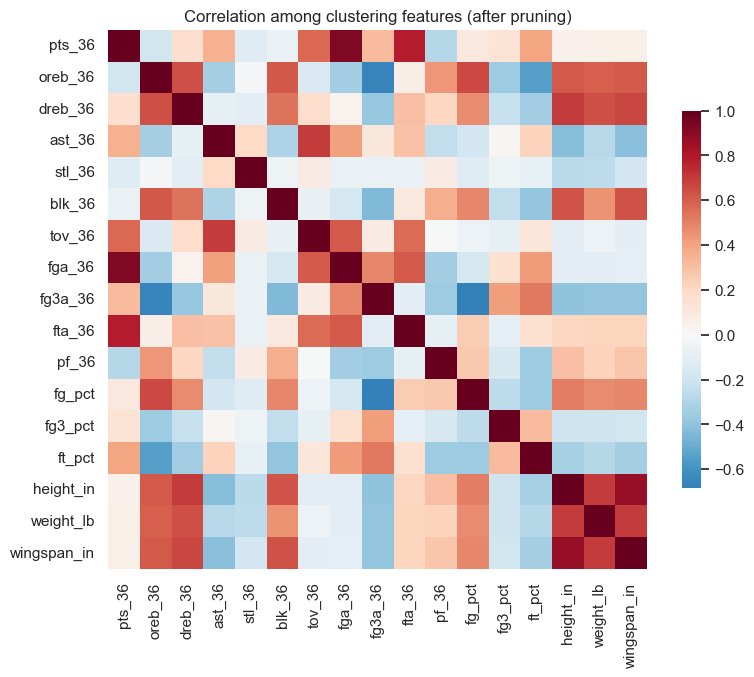

In [69]:
corr = df[cluster_features].corr().abs()
pairs = (corr.where(np.triu(np.ones(corr.shape), 1).astype(bool))
             .stack().sort_values(ascending=False))
print("Highest remaining |correlation| pairs:")
print(pairs.head(6).round(3).to_string())

plt.figure(figsize=(9, 7))
sns.heatmap(df[cluster_features].corr(), cmap="RdBu_r", center=0, square=True,
            cbar_kws={"shrink": .7})
plt.title("Correlation among clustering features (after pruning)")
plt.show()

# Clustering - Standardize
### k-means is scale-sensitive. Must use StandardScaler  to get z-scores for each column

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cluster_X = scaler.fit_transform(df[cluster_features])
print("scaled matrix:", cluster_X.shape)

scaled matrix: (379, 17)


# Clustering - Export Pickle

In [71]:
import joblib

# Save cluster_X to your Data folder
joblib.dump(cluster_X, '../Data/cluster_X.pkl')

['../Data/cluster_X.pkl']

# Model - Train Test Split

In [72]:
from sklearn.model_selection import train_test_split

# Drop 16 players with no salary before splitting.
# Clustering above still uses all players beacuse it does not depend on salary
model_df = df.dropna(subset=['log_salary']).copy()

X = model_df[model_features]
y = model_df['log_salary']

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model - Standardize
### Scaling is not needed for Random Forest, but may be needed for other model types

In [73]:
scaler = StandardScaler()

X_train[model_features] = scaler.fit_transform(X_train[model_features])

X_test[model_features] = scaler.transform(X_test[model_features])

# Model - Export Pickle

In [74]:
#this will be used in modeling next
import joblib

# Save as a dictionary or individual files
data_split = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test
}

joblib.dump(data_split, '../Data/nba_modeling_data.pkl')

['../Data/nba_modeling_data.pkl']

# Export Dataset

In [75]:
# save the data to a new csv file
filepath = '../Data/nba-3-preprocessing.csv'
df.to_csv(filepath, index=False)

# Summary

<br> - Loaded CSV dataset from Step 2
<br> - Converted count features to per 36 minutes
<br> - Plotted correlation heatmap for all cluster features
<br> - Standardized the cluster and model data
<br> - Dropped players with no salary on record so the model target has no missing values
<br> - Split the model data into train and test sets
<br> - The next steps will be: <li>1) creating the cluster to give context on the player archetypes<li>2) creating the salary model <li>3) looking for gaps in pay